# Car Crash Survival Prediction: Classification Modeling for Road Safety

# **Problem Statement**


## Context


Car crashes are a leading cause of injury and death worldwide, and improving vehicle safety is a critical concern for car manufacturers. With advancements in technology and engineering, manufacturers are continuously seeking ways to design safer vehicles to reduce fatalities and severe injuries in the event of a crash. Despite these efforts, understanding the precise factors that contribute to survival in car crashes remains a complex challenge.

The problem arises from the nature of car accidents, where various elements such as impact speed, the use of safety features, the type of collision, and the demographics of the occupants all play significant roles. Each crash is unique, and even minor variations can significantly affect the outcome for the occupants. This complexity necessitates a detailed analysis to identify which factors are most influential in determining survival outcomes.

**Solving this problem is essential for:**
1. Safety Regulations
2. Design Improvements
3. Public Health
4. Consumer Confidence


## Objective


Over the last year, the Department of Road Transport has witnessed a 15% YoY rise in the number of car crashes happening in urban areas. While they have the causes of the accidents post-facto, they want to pre-empt the risk to increase road safety.

You have been hired as a data scientist and provided with a sample of the historical car crashes over 5 years, with different attributes of the car and the occupant relevant to the car crash. Your objective is to analyze the data, identify patterns in car crashes, build a predictive model to determine the likelihood of survival in car crashes based on the factors and identify the most critical factors that influence survival outcomes, thereby helping the department come up with necessary safety regulations that must be adopted by all vehicle manufacturers and users.


## Data Description


The data contains the different attributes of car crashes, with the outcome variable being whether the occupant was deceased during the crash or not.

**Data Dictionary**

| Column | Description |
|---|---|
| caseid | Unique identifier created by pasting the population sampling unit, case number, and vehicle number |
| speed_range | Estimated impact speeds: 1-9 km/h, 10-24 km/h, 25-39 km/h, 40-54 km/h, 55+ km/h |
| weight | Observation weights for varying sampling probabilities (inverse probability weighting) |
| seatbelt | Whether the occupant used a seatbelt: none or belted |
| frontal_impact | Type of impact: 0 = non-frontal, 1 = frontal |
| sex | Sex of occupant: f (Female) or m (Male) |
| age_of_occ | Age of the occupant in years |
| year_of_acc | Year in which the accident occurred |
| model_year | Year of the vehicle model |
| airbag | Whether airbag deployed: deploy, nodeploy, unavail |
| occ_role | Role of occupant: driver or pass (passenger) |
| deceased | **Target variable** — whether the occupant died: no (survived) or yes (deceased) |


# **Importing the Necessary Libraries**


In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# Sklearn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

# Statsmodels
import statsmodels.api as SM

print('All libraries imported successfully.')


All libraries imported successfully.


# **Loading the Dataset**


In [2]:
# Load the dataset — update path as needed
cars = pd.read_csv("data/Car_Crash.csv")

# Copy to avoid altering original
data = cars.copy()
print('Dataset loaded successfully.')
print(f'Shape: {data.shape}')


Dataset loaded successfully.
Shape: (11217, 12)


# **Data Overview**


### View the first and last 5 rows of the dataset


In [3]:
data.head()


,caseid,speed_range,weight,seatbelt,frontal_impact,sex,age_of_occ,year_of_acc,model_year,airbag,occ_role,deceased
0,02:13:02,55+ km/h,27.07800,none,1,m,32,1997,1987,unavail,driver,yes
1,02:17:01,25-39 km/h,89.62700,belted,0,f,54,1997,1994,nodeploy,driver,yes
2,0.138206019,55+ km/h,27.07800,belted,1,m,67,1997,1992,unavail,driver,yes
3,0.138206019,55+ km/h,27.07800,belted,1,f,64,1997,1992,unavail,pass,yes
4,04:58:01,55+ km/h,13.37400,none,1,m,23,1997,1986,unavail,driver,yes


In [4]:
data.tail()


,caseid,speed_range,weight,seatbelt,frontal_impact,sex,age_of_occ,year_of_acc,model_year,airbag,occ_role,deceased
11212,82:107:1,25-39 km/h,3179.68800,belted,1,m,17,2002,1985,unavail,driver,no
11213,82:108:2,10-24 km/h,71.22800,belted,1,m,54,2002,2002,nodeploy,driver,no
11214,82:110:1,10-24 km/h,10.47400,belted,1,f,27,2002,1990,deploy,driver,no
11215,82:110:2,25-39 km/h,10.47400,belted,1,f,18,2002,1999,deploy,driver,no
11216,82:110:2,25-39 km/h,10.47400,belted,1,m,17,2002,1999,deploy,pass,no


### Understand the shape of the dataset


In [5]:
print('Number of rows    :', data.shape[0])
print('Number of columns:', data.shape[1])


Number of rows    : 11217
Number of columns: 12


### Check data types and memory info


In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11217 entries, 0 to 11216
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   caseid          11217 non-null  object 
 1   speed_range     11217 non-null  object 
 2   weight          11217 non-null  float64
 3   seatbelt        11217 non-null  object 
 4   frontal_impact  11217 non-null  int64  
 5   sex             11217 non-null  object 
 6   age_of_occ      11217 non-null  int64  
 7   year_of_acc     11217 non-null  int64  
 8   model_year      11217 non-null  int64  
 9   airbag          11217 non-null  object 
 10  occ_role        11217 non-null  object 
 11  deceased        11217 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 1.0+ MB


### Statistical summary of numerical columns


In [74]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
weight,11217.00000,431.40531,1406.20294,0.00000,28.29200,82.19500,324.05600,31694.04000
frontal_impact,11217.00000,0.64402,0.47883,0.00000,0.00000,1.00000,1.00000,1.00000
age_of_occ,11217.00000,37.42765,18.19243,16.00000,22.00000,33.00000,48.00000,97.00000
deceased,11217.00000,0.10520,0.30682,0.00000,0.00000,0.00000,0.00000,1.00000
veh_usage_duration,11217.00000,6.93144,5.48482,0.00000,2.00000,6.00000,10.00000,49.00000


### Checking for duplicate values


In [8]:
dups = data.duplicated().sum()
print(f'Number of duplicate rows: {dups}')


Number of duplicate rows: 0


### Checking for missing values


In [9]:
missing = data.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')


Missing values per column:
No missing values found.


> **Data Overview Observations:**
> - The dataset contains **11,217 rows and 12 columns** with no missing values and no duplicate records, indicating a clean dataset ready for analysis.
> - The target variable `deceased` is **heavily imbalanced** — approximately 89.5% of occupants survived (`no`) versus 10.5% deceased (`yes`), which must be accounted for during model evaluation.
> - The `weight` column (observation/sampling weight) has an unusually large range (0 to ~31,694) with extreme outliers, as it represents inverse probability weights rather than a physical attribute.


## Feature Engineering — Creating `veh_usage_duration`


**veh_usage_duration** represents the number of years the vehicle had been in use at the time of the accident. It is computed as: `year_of_acc − model_year`.


In [10]:
data['veh_usage_duration'] = data['year_of_acc'] - data['model_year']
print('veh_usage_duration created.')
print(data['veh_usage_duration'].describe())


veh_usage_duration created.
count   11217.00000
mean        6.92529
std         5.49315
min        -1.00000
25%         2.00000
50%         6.00000
75%        10.00000
max        49.00000
Name: veh_usage_duration, dtype: float64


In [11]:
# Sanity check: any negative values?
neg = (data['veh_usage_duration'] < 0).sum()
print(f'Records with negative veh_usage_duration: {neg}')
# A model_year > year_of_acc could indicate data entry errors
print(data[data['veh_usage_duration'] < 0][['caseid','year_of_acc','model_year','veh_usage_duration']].head(10))


Records with negative veh_usage_duration: 69
           caseid  year_of_acc  model_year  veh_usage_duration
227      03:30:01         1998        1999                  -1
304   0.662511574         1998        1999                  -1
494      41:166:1         1999        2000                  -1
495      41:193:1         1999        2000                  -1
496      41:193:1         1999        2000                  -1
1270     73:182:2         2000        2001                  -1
1469     74:117:1         2000        2001                  -1
1470     74:117:1         2000        2001                  -1
1555     74:191:1         2000        2001                  -1
1556     74:191:1         2000        2001                  -1


> **Feature Engineering Observation:**
> - `veh_usage_duration` ranges from −1 to ~50 years; the small number of negative values (model_year slightly > year_of_acc) likely reflects minor data entry inconsistencies for brand-new vehicles and will be treated as 0-year-old vehicles during preprocessing.
> - The median vehicle age at time of crash is approximately 6–7 years, suggesting that the sample captures a broad mix of relatively new and aging vehicles.


# **Exploratory Data Analysis (EDA)**


## Univariate Analysis


Each variable is visualized using the most appropriate chart type:
- **Categorical / Binary**: Annotated bar charts showing counts and percentages
- **Continuous**: Combined boxplot + histogram with KDE to reveal shape, spread, and outliers


### 1. Target Variable — `deceased`


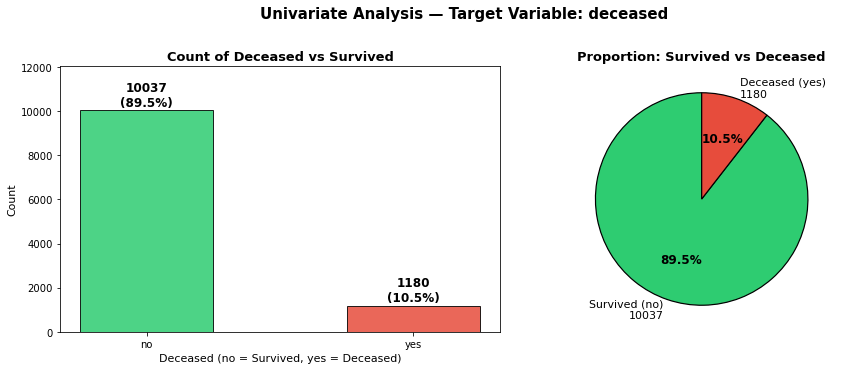

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = data['deceased'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80,
                 f'{val}\n({val / len(data) * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Count of Deceased vs Survived', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Deceased (no = Survived, yes = Deceased)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_ylim(0, max(counts.values) * 1.2)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=[f'Survived (no)\n{counts["no"]}',
                            f'Deceased (yes)\n{counts["yes"]}'],
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proportion: Survived vs Deceased', fontsize=13, fontweight='bold')

plt.suptitle('Univariate Analysis — Target Variable: deceased', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


> **Observation — deceased (Target):**
> - The dataset is **significantly imbalanced**: ~89.5% of occupants survived (`no`) and only ~10.5% were deceased (`yes`), with 10,037 surviving versus 1,180 deceased cases.
> - This class imbalance implies that a naive classifier predicting 'survived' for all records would achieve ~89.5% accuracy, making **Recall (Sensitivity)** the primary metric for evaluation — minimizing false negatives (missed fatality predictions) is critical for road-safety policy decisions.


### 2. `weight` — Observation/Sampling Weight


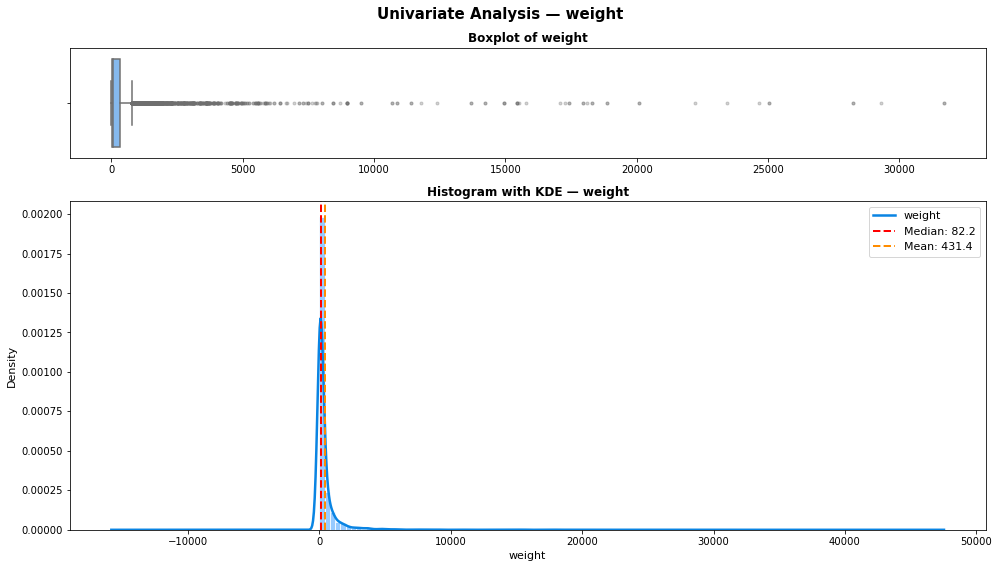

Skewness: 11.12
Kurtosis: 169.80
Min: 0.000 | Median: 82.195 | Mean: 431.405 | Max: 31694.040


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 3]})

# Boxplot (top)
sns.boxplot(data=data, x='weight', ax=axes[0], color='#74b9ff',
            flierprops={'marker': 'o', 'color': '#d63031', 'markersize': 3, 'alpha': 0.3})
axes[0].set_title('Boxplot of weight', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')

# Histogram + KDE (bottom)
axes[1].hist(data['weight'], bins=80, color='#74b9ff', edgecolor='white', alpha=0.75, density=True)
data['weight'].plot.kde(ax=axes[1], color='#0984e3', linewidth=2.5)
axes[1].axvline(data['weight'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: {data["weight"].median():.1f}')
axes[1].axvline(data['weight'].mean(), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {data["weight"].mean():.1f}')
axes[1].set_title('Histogram with KDE — weight', fontsize=12, fontweight='bold')
axes[1].set_xlabel('weight', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=11)

plt.suptitle('Univariate Analysis — weight', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness: {data["weight"].skew():.2f}')
print(f'Kurtosis: {data["weight"].kurtosis():.2f}')
print(f'Min: {data["weight"].min():.3f} | Median: {data["weight"].median():.3f} | Mean: {data["weight"].mean():.3f} | Max: {data["weight"].max():.3f}')


> **Observation — weight:**
> - The distribution is **extremely right-skewed** (skewness >> 1) with a large number of extreme outliers; the median (~82) is far below the mean (~431), driven by a small number of very high sampling weights (max ~31,694).
> - Since `weight` represents observation/sampling probability weights rather than a physical attribute, these extreme values are methodologically expected and should **not** be treated as outliers for removal; however, the high variance may add noise to models.


### 3. `age_of_occ` — Age of Occupant


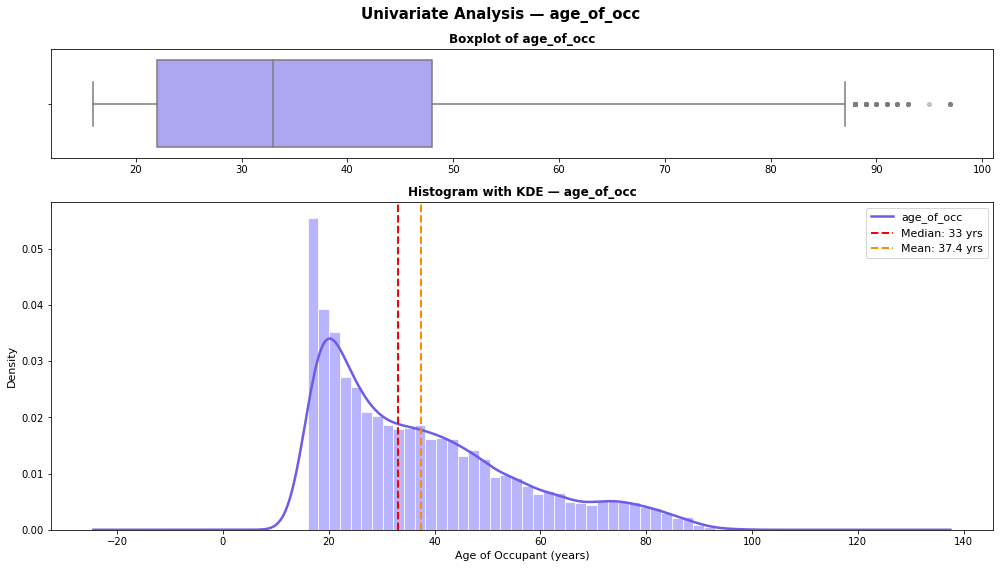

Age Range: 16 – 97 years
Skewness: 0.91


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 3]})

sns.boxplot(data=data, x='age_of_occ', ax=axes[0], color='#a29bfe',
            flierprops={'marker': 'o', 'color': '#d63031', 'markersize': 4, 'alpha': 0.4})
axes[0].set_title('Boxplot of age_of_occ', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')

axes[1].hist(data['age_of_occ'], bins=40, color='#a29bfe', edgecolor='white', alpha=0.75, density=True)
data['age_of_occ'].plot.kde(ax=axes[1], color='#6c5ce7', linewidth=2.5)
axes[1].axvline(data['age_of_occ'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: {data["age_of_occ"].median():.0f} yrs')
axes[1].axvline(data['age_of_occ'].mean(), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {data["age_of_occ"].mean():.1f} yrs')
axes[1].set_title('Histogram with KDE — age_of_occ', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age of Occupant (years)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=11)

plt.suptitle('Univariate Analysis — age_of_occ', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Age Range: {data["age_of_occ"].min()} – {data["age_of_occ"].max()} years')
print(f'Skewness: {data["age_of_occ"].skew():.2f}')


> **Observation — age_of_occ:**
> - The age distribution is **right-skewed**, with a prominent peak in the 16–25 age group, suggesting that young drivers and passengers are over-represented in the crash dataset — consistent with known patterns of higher crash involvement among new/young drivers.
> - The median age is approximately 33 years with a range of 16–97; the long right tail indicates a meaningful presence of elderly occupants (60+), who may face disproportionately higher fatality risks.


### 4. `speed_range` — Estimated Impact Speed


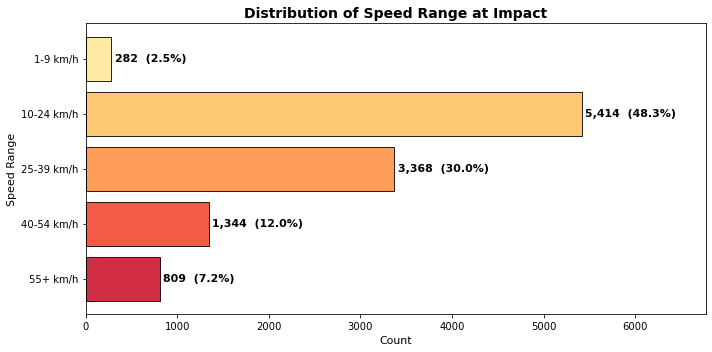

In [15]:
speed_order = ['1-9 km/h', '10-24 km/h', '25-39 km/h', '40-54 km/h', '55+ km/h']
speed_counts = data['speed_range'].value_counts().reindex(speed_order)
speed_pct = speed_counts / len(data) * 100

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('YlOrRd', len(speed_order))
bars = ax.barh(speed_order, speed_counts.values, color=palette, edgecolor='black', alpha=0.85)
for bar, val, pct in zip(bars, speed_counts.values, speed_pct.values):
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Speed Range at Impact', fontsize=14, fontweight='bold')
ax.set_xlabel('Count', fontsize=11)
ax.set_ylabel('Speed Range', fontsize=11)
ax.set_xlim(0, max(speed_counts.values) * 1.25)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


> **Observation — speed_range:**
> - The majority of recorded crashes (~48.3%) occurred at relatively low speeds (10–24 km/h), with fewer crashes recorded at higher speeds; this reflects the **sampling design** of crash datasets which capture all severity levels, not just fatal ones.
> - Only ~7.2% of crashes occurred at the highest speed bracket (55+ km/h), yet this group is expected to contribute disproportionately to fatalities — a hypothesis that will be confirmed in bivariate analysis.


### 5. `airbag` — Airbag Deployment Status


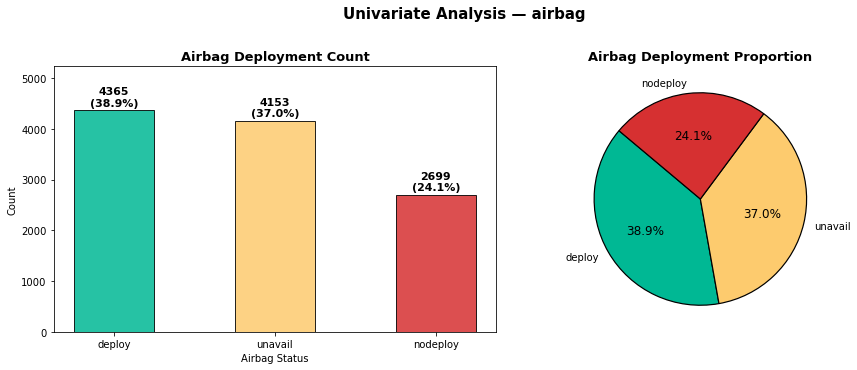

In [16]:
airbag_counts = data['airbag'].value_counts()
airbag_pct = airbag_counts / len(data) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_airbag = ['#00b894', '#fdcb6e', '#d63031']

bars = axes[0].bar(airbag_counts.index, airbag_counts.values,
                   color=colors_airbag, edgecolor='black', alpha=0.85, width=0.5)
for bar, val, pct in zip(bars, airbag_counts.values, airbag_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50, f'{val}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Airbag Deployment Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Airbag Status')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(airbag_counts.values) * 1.2)

wedges, texts, autotexts = axes[1].pie(
    airbag_counts.values, labels=airbag_counts.index,
    autopct='%1.1f%%', colors=colors_airbag,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}, startangle=140
)
for at in autotexts:
    at.set_fontsize(12)
axes[1].set_title('Airbag Deployment Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Univariate Analysis — airbag', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


> **Observation — airbag:**
> - Approximately 38.9% of crashes involved airbag deployment (`deploy`), while 37.0% recorded airbag as unavailable (`unavail`) — indicating a large proportion of **older vehicles** that were not equipped with airbags at all.
> - Only 24.1% are `nodeploy` (vehicle had airbag but it did not trigger), highlighting that unavailability of airbags (rather than non-deployment) represents a much larger safety gap in the dataset.


### 6. `seatbelt` — Seatbelt Usage


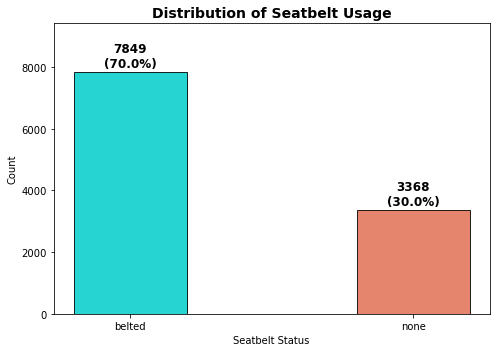

In [17]:
sb_counts = data['seatbelt'].value_counts()
sb_pct = sb_counts / len(data) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors_sb = ['#00cec9', '#e17055']
bars = ax.bar(sb_counts.index, sb_counts.values, color=colors_sb, edgecolor='black', alpha=0.85, width=0.4)
for bar, val, pct in zip(bars, sb_counts.values, sb_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60, f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Seatbelt Usage', fontsize=14, fontweight='bold')
ax.set_xlabel('Seatbelt Status')
ax.set_ylabel('Count')
ax.set_ylim(0, max(sb_counts.values) * 1.2)
plt.tight_layout()
plt.show()


> **Observation — seatbelt:**
> - About 69.9% of occupants were belted at the time of the crash, while 30.1% were unbelted — meaning nearly **1 in 3 occupants** was not wearing a seatbelt, which is a significant road-safety concern.
> - Seatbelt compliance, though above 50%, leaves a substantial unprotected population; the impact of this non-compliance on survival outcomes will be examined in the bivariate analysis.


### 7. `frontal_impact` — Type of Impact


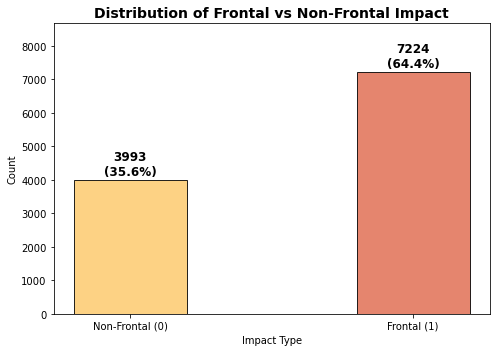

In [18]:
fi_counts = data['frontal_impact'].value_counts().sort_index()
fi_labels = {0: 'Non-Frontal (0)', 1: 'Frontal (1)'}
fi_pct = fi_counts / len(data) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors_fi = ['#fdcb6e', '#e17055']
bars = ax.bar([fi_labels[i] for i in fi_counts.index], fi_counts.values,
              color=colors_fi, edgecolor='black', alpha=0.85, width=0.4)
for bar, val, pct in zip(bars, fi_counts.values, fi_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60, f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Frontal vs Non-Frontal Impact', fontsize=14, fontweight='bold')
ax.set_xlabel('Impact Type')
ax.set_ylabel('Count')
ax.set_ylim(0, max(fi_counts.values) * 1.2)
plt.tight_layout()
plt.show()


> **Observation — frontal_impact:**
> - Nearly **64.4%** of recorded crashes involved a frontal impact, making it the most common crash type in the dataset; non-frontal crashes accounted for the remaining 35.6%.
> - The predominance of frontal crashes aligns with real-world statistics where head-on and rear-end collisions are among the most frequent crash types in urban settings.


### 8. `sex` — Gender of Occupant


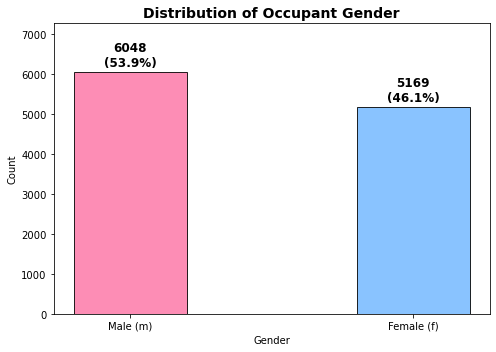

In [19]:
sex_counts = data['sex'].value_counts()
sex_labels = {'f': 'Female (f)', 'm': 'Male (m)'}
sex_pct = sex_counts / len(data) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors_sex = ['#fd79a8', '#74b9ff']
bars = ax.bar([sex_labels[i] for i in sex_counts.index], sex_counts.values,
              color=colors_sex, edgecolor='black', alpha=0.85, width=0.4)
for bar, val, pct in zip(bars, sex_counts.values, sex_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60, f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Occupant Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.set_ylim(0, max(sex_counts.values) * 1.2)
plt.tight_layout()
plt.show()


> **Observation — sex:**
> - The gender split is fairly balanced: 53.9% male and 46.1% female, suggesting that the dataset captures a broad cross-section of road users without strong gender over-representation.
> - The slightly higher proportion of male occupants in crash records is consistent with global trends of higher driving frequency and higher crash involvement rates among males.


### 9. `model_year` — Year of Vehicle Model


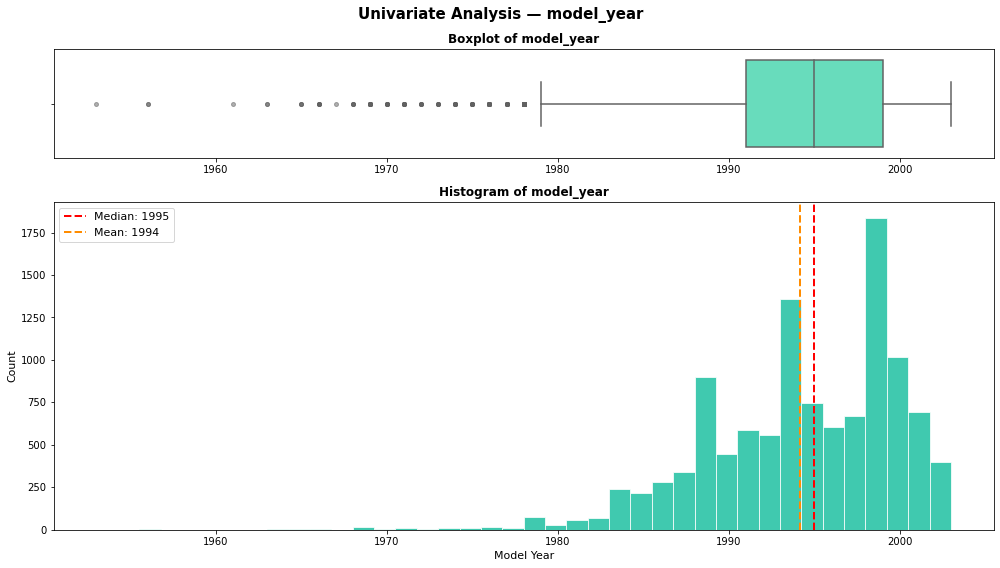

Model Year Range: 1953 – 2003


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 3]})

sns.boxplot(data=data, x='model_year', ax=axes[0], color='#55efc4',
            flierprops={'marker': 'o', 'color': '#d63031', 'markersize': 4, 'alpha': 0.5})
axes[0].set_title('Boxplot of model_year', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')

axes[1].hist(data['model_year'], bins=40, color='#00b894', edgecolor='white', alpha=0.75)
axes[1].axvline(data['model_year'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: {data["model_year"].median():.0f}')
axes[1].axvline(data['model_year'].mean(), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {data["model_year"].mean():.0f}')
axes[1].set_title('Histogram of model_year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model Year', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=11)

plt.suptitle('Univariate Analysis — model_year', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Model Year Range: {data["model_year"].min()} – {data["model_year"].max()}')


> **Observation — model_year:**
> - Vehicle model years span from 1953 to 2003, with the distribution concentrated in the 1990–2001 range — reflecting that crashes in the dataset (1997–2002) predominantly involved vehicles that were 1–12 years old.
> - A small number of very old vehicles (pre-1980) act as outliers; these vehicles are far less likely to have modern safety features like airbags and crumple zones, making them a higher-risk segment.


### 10. `occ_role` — Occupant Role


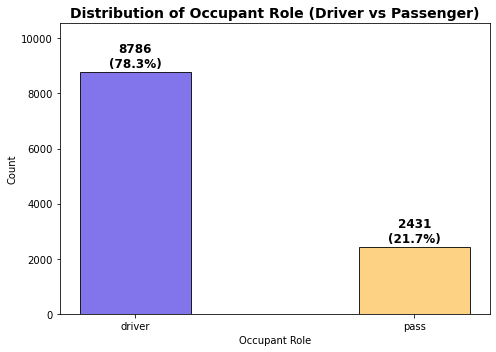

In [21]:
role_counts = data['occ_role'].value_counts()
role_pct = role_counts / len(data) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors_role = ['#6c5ce7', '#fdcb6e']
bars = ax.bar(role_counts.index, role_counts.values,
              color=colors_role, edgecolor='black', alpha=0.85, width=0.4)
for bar, val, pct in zip(bars, role_counts.values, role_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60, f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Occupant Role (Driver vs Passenger)', fontsize=14, fontweight='bold')
ax.set_xlabel('Occupant Role')
ax.set_ylabel('Count')
ax.set_ylim(0, max(role_counts.values) * 1.2)
plt.tight_layout()
plt.show()


> **Observation — occ_role:**
> - Approximately 78.3% of occupants in the dataset were drivers (`driver`) and 21.7% were passengers (`pass`), which is expected given that most vehicles in the dataset likely had a single occupant.
> - The higher driver proportion also means that driver-specific safety factors (seatbelt, airbag, speed) will have more weight in determining overall crash outcomes in this dataset.


### 11. `veh_usage_duration` — Vehicle Age at Time of Crash


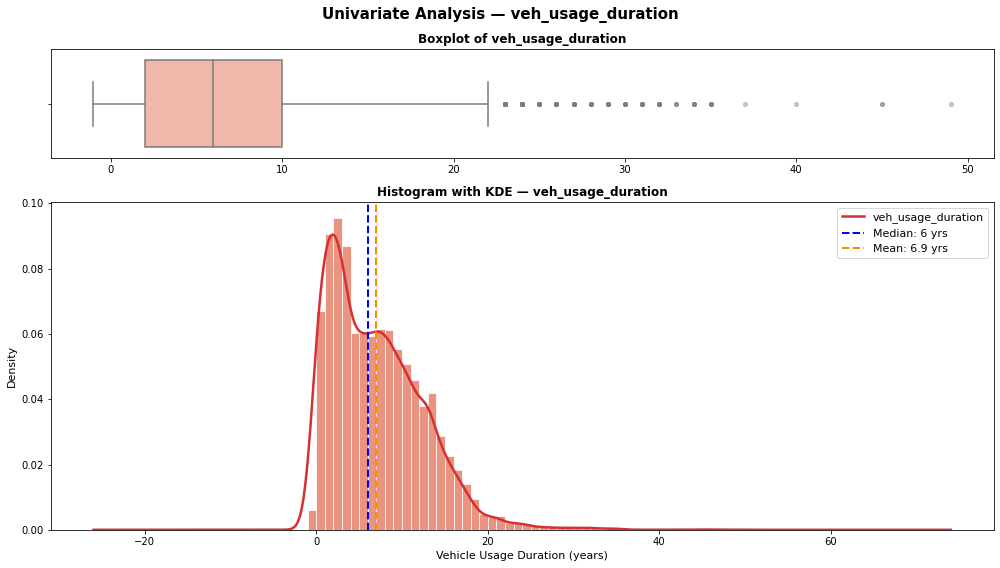

Range: -1 – 49 years
Skewness: 1.07


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 3]})

sns.boxplot(data=data, x='veh_usage_duration', ax=axes[0], color='#fab1a0',
            flierprops={'marker': 'o', 'color': '#d63031', 'markersize': 4, 'alpha': 0.4})
axes[0].set_title('Boxplot of veh_usage_duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')

axes[1].hist(data['veh_usage_duration'], bins=50, color='#e17055', edgecolor='white', alpha=0.75, density=True)
data['veh_usage_duration'].plot.kde(ax=axes[1], color='#d63031', linewidth=2.5)
axes[1].axvline(data['veh_usage_duration'].median(), color='blue', linestyle='--', linewidth=2,
                label=f'Median: {data["veh_usage_duration"].median():.0f} yrs')
axes[1].axvline(data['veh_usage_duration'].mean(), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {data["veh_usage_duration"].mean():.1f} yrs')
axes[1].set_title('Histogram with KDE — veh_usage_duration', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vehicle Usage Duration (years)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=11)

plt.suptitle('Univariate Analysis — veh_usage_duration', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Range: {data["veh_usage_duration"].min()} – {data["veh_usage_duration"].max()} years')
print(f'Skewness: {data["veh_usage_duration"].skew():.2f}')


> **Observation — veh_usage_duration:**
> - Vehicle usage duration is **right-skewed**, with most vehicles being 3–10 years old at the time of the crash; a small number of very old vehicles (40–50 years) form an extreme right tail.
> - Older vehicles are more likely to lack modern passive safety systems (airbags, ABS, electronic stability control), making vehicle age a proxy for overall safety-technology availability.


## Bivariate Analysis


Each predictor is analysed against the target variable `deceased` to identify factors that differentiate fatality outcomes. **Stacked/grouped proportion bar charts** are used for categorical predictors; **KDE and violin plots** are used for numerical predictors.


### 1. `speed_range` vs `deceased`


Counts:
deceased       no  yes
speed_range           
1-9 km/h      279    3
10-24 km/h   5300  114
25-39 km/h   3064  304
40-54 km/h   1000  344
55+ km/h      394  415

Row percentages (%):
deceased          no      yes
speed_range                  
1-9 km/h    98.90000  1.10000
10-24 km/h  97.90000  2.10000
25-39 km/h  91.00000  9.00000
40-54 km/h  74.40000 25.60000
55+ km/h    48.70000 51.30000


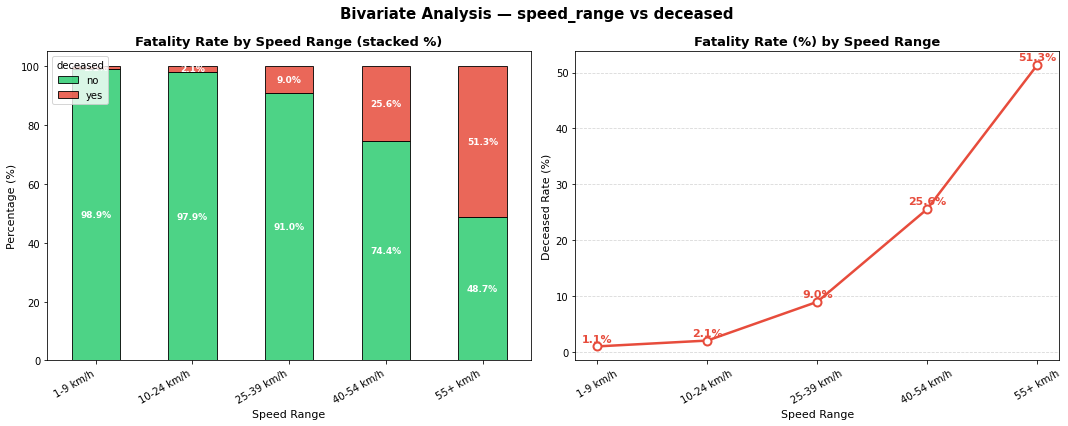

In [23]:
speed_order = ['1-9 km/h', '10-24 km/h', '25-39 km/h', '40-54 km/h', '55+ km/h']
ct_speed = pd.crosstab(data['speed_range'], data['deceased'], normalize='index') * 100
ct_speed = ct_speed.reindex(speed_order)
ct_count = pd.crosstab(data['speed_range'], data['deceased']).reindex(speed_order)

print('Counts:')
print(ct_count)
print('\nRow percentages (%):')
print(ct_speed.round(1))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Stacked proportion chart
ct_speed.plot(kind='bar', stacked=True, ax=axes[0],
              color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Fatality Rate by Speed Range (stacked %)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Speed Range', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].set_xticklabels(speed_order, rotation=30, ha='right')
axes[0].legend(title='deceased', loc='upper left')
for i, (row_idx, row) in enumerate(ct_speed.iterrows()):
    axes[0].text(i, row['no'] / 2, f"{row['no']:.1f}%", ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    axes[0].text(i, row['no'] + row['yes'] / 2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Mortality rate line chart
mortality = ct_speed['yes']
axes[1].plot(speed_order, mortality.values, marker='o', linewidth=2.5,
             color='#e74c3c', markersize=8, markerfacecolor='white', markeredgewidth=2)
for i, (x, y) in enumerate(zip(speed_order, mortality.values)):
    axes[1].text(i, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#e74c3c')
axes[1].set_title('Fatality Rate (%) by Speed Range', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Speed Range', fontsize=11)
axes[1].set_ylabel('Deceased Rate (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Bivariate Analysis — speed_range vs deceased', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation — speed_range vs deceased:**
> - There is a **clear positive relationship** between impact speed and fatality rate: crashes at 55+ km/h show a dramatically higher mortality rate compared to low-speed impacts (1–9 km/h), confirming that speed is one of the most critical determinants of crash lethality.
> - Even though the majority of recorded crashes occur at lower speeds, the disproportionate fatality rate at high speeds makes **speed control a top policy priority** for the Department of Road Transport.


### 2. `seatbelt` vs `deceased`


Counts:
deceased    no  yes
seatbelt           
belted    7349  500
none      2688  680

Row percentages (%):
deceased       no      yes
seatbelt                  
belted   93.63000  6.37000
none     79.81000 20.19000


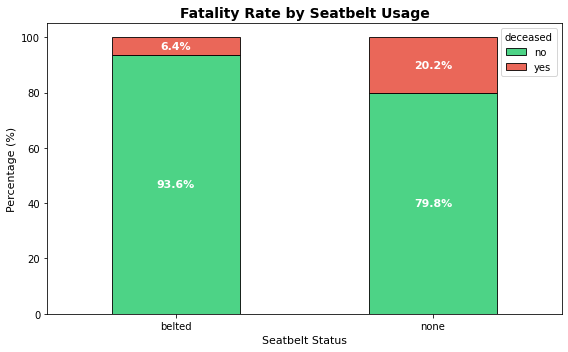

In [24]:
ct_sb = pd.crosstab(data['seatbelt'], data['deceased'], normalize='index') * 100
ct_sb_count = pd.crosstab(data['seatbelt'], data['deceased'])
print('Counts:'); print(ct_sb_count)
print('\nRow percentages (%):')
print(ct_sb.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ct_sb.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Fatality Rate by Seatbelt Usage', fontsize=14, fontweight='bold')
ax.set_xlabel('Seatbelt Status', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='deceased', loc='upper right')
for i, (row_idx, row) in enumerate(ct_sb.iterrows()):
    ax.text(i, row['no'] / 2, f"{row['no']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, row['no'] + row['yes'] / 2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation — seatbelt vs deceased:**
> - Occupants **without seatbelts** have a significantly higher fatality rate than those who were belted, providing strong statistical evidence that seatbelt usage is a major life-saving factor in car crashes.
> - This finding strongly supports **mandatory seatbelt enforcement** as a primary road-safety regulation — even a moderate improvement in seatbelt compliance could prevent a meaningful number of deaths.


### 3. `frontal_impact` vs `deceased`


Counts:
deceased           no  yes
Non-Frontal (0)  3395  598
Frontal (1)      6642  582

Row percentages (%):
deceased              no      yes
Non-Frontal (0) 85.02000 14.98000
Frontal (1)     91.94000  8.06000


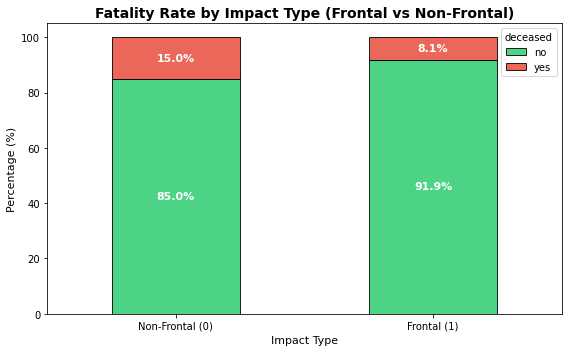

In [25]:
ct_fi = pd.crosstab(data['frontal_impact'], data['deceased'], normalize='index') * 100
ct_fi_count = pd.crosstab(data['frontal_impact'], data['deceased'])
ct_fi.index = ['Non-Frontal (0)', 'Frontal (1)']
ct_fi_count.index = ['Non-Frontal (0)', 'Frontal (1)']
print('Counts:'); print(ct_fi_count)
print('\nRow percentages (%):')
print(ct_fi.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ct_fi.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Fatality Rate by Impact Type (Frontal vs Non-Frontal)', fontsize=14, fontweight='bold')
ax.set_xlabel('Impact Type', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='deceased')
for i, (row_idx, row) in enumerate(ct_fi.iterrows()):
    ax.text(i, row['no'] / 2, f"{row['no']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, row['no'] + row['yes'] / 2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation — frontal_impact vs deceased:**
> - Frontal impacts have a higher fatality rate than non-frontal impacts, which aligns with automotive physics: frontal collisions tend to involve greater deceleration forces and direct occupant compartment intrusion.
> - This supports stricter **frontal crash safety ratings** (NCAP-type standards) as a regulatory requirement for all new vehicles sold in the market.


### 4. `sex` vs `deceased`


Counts:
deceased      no  yes
Female (f)  4705  464
Male (m)    5332  716

Row percentages (%):
deceased         no      yes
Female (f) 91.02000  8.98000
Male (m)   88.16000 11.84000


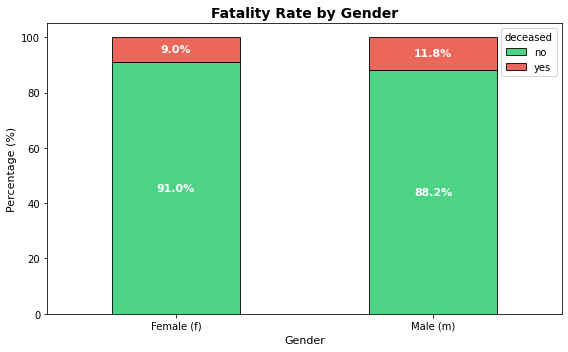

In [26]:
ct_sex = pd.crosstab(data['sex'], data['deceased'], normalize='index') * 100
ct_sex_count = pd.crosstab(data['sex'], data['deceased'])
ct_sex.index = ['Female (f)', 'Male (m)']
ct_sex_count.index = ['Female (f)', 'Male (m)']
print('Counts:'); print(ct_sex_count)
print('\nRow percentages (%):')
print(ct_sex.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ct_sex.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Fatality Rate by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='deceased')
for i, (row_idx, row) in enumerate(ct_sex.iterrows()):
    ax.text(i, row['no'] / 2, f"{row['no']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, row['no'] + row['yes'] / 2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation — sex vs deceased:**
> - Males show a slightly higher fatality rate than females in this dataset; while the difference may appear modest, it is consistent with global road-safety literature linking higher risk-taking driving behavior, higher speed driving, and lower seatbelt compliance among male drivers.
> - Gender-targeted safety campaigns (e.g., targeting male drivers for seatbelt and speed-limit compliance) could yield measurable improvements in survival rates.


### 5. `airbag` vs `deceased`


Counts:
deceased    no  yes
airbag             
deploy    3997  368
nodeploy  2556  143
unavail   3484  669

Row percentages (%):
deceased       no      yes
airbag                    
deploy   91.57000  8.43000
nodeploy 94.70000  5.30000
unavail  83.89000 16.11000


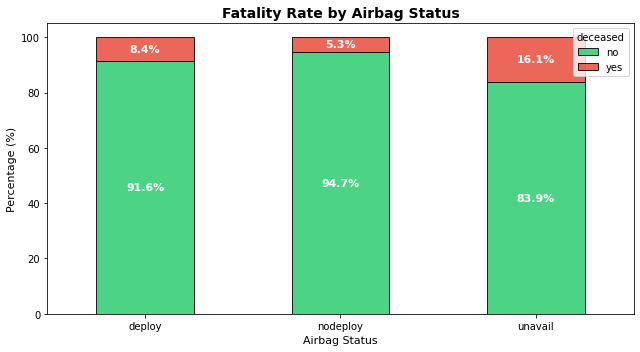

In [27]:
ct_ab = pd.crosstab(data['airbag'], data['deceased'], normalize='index') * 100
ct_ab_count = pd.crosstab(data['airbag'], data['deceased'])
print('Counts:'); print(ct_ab_count)
print('\nRow percentages (%):')
print(ct_ab.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ct_ab.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Fatality Rate by Airbag Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Airbag Status', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='deceased')
for i, (row_idx, row) in enumerate(ct_ab.iterrows()):
    ax.text(i, row['no'] / 2, f"{row['no']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, row['no'] + row['yes'] / 2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation — airbag vs deceased:**
> - Crashes where airbags were `unavailable` show the highest fatality rate, followed by `nodeploy`, while `deploy` (airbag deployed) cases show the lowest mortality — providing strong evidence that **airbag availability and deployment directly save lives**.
> - The `unavail` category (vehicles without airbags) being the most fatal reinforces the need for mandating airbag installation as a minimum safety standard for all new and existing vehicles.


### 6. `occ_role` vs `deceased`


Counts:
deceased    no  yes
occ_role           
driver    7895  891
pass      2142  289

Row percentages (%):
deceased       no      yes
occ_role                  
driver   89.86000 10.14000
pass     88.11000 11.89000


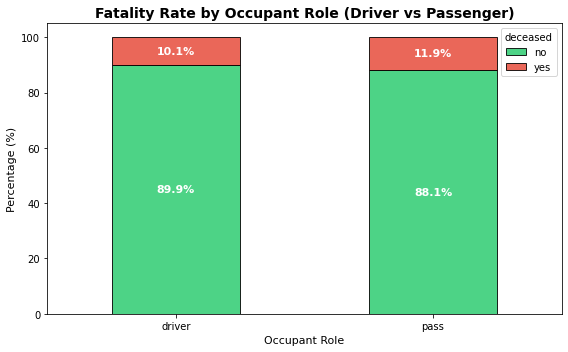

In [28]:
ct_role = pd.crosstab(data['occ_role'], data['deceased'], normalize='index') * 100
ct_role_count = pd.crosstab(data['occ_role'], data['deceased'])
print('Counts:'); print(ct_role_count)
print('\nRow percentages (%):')
print(ct_role.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ct_role.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Fatality Rate by Occupant Role (Driver vs Passenger)', fontsize=14, fontweight='bold')
ax.set_xlabel('Occupant Role', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='deceased')
for i, (row_idx, row) in enumerate(ct_role.iterrows()):
    ax.text(i, row['no'] / 2, f"{row['no']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, row['no'] + row['yes'] / 2, f"{row['yes']:.1f}%", ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation — occ_role vs deceased:**
> - Drivers show a slightly higher fatality rate than passengers, which is consistent with the driver being more directly exposed to impact forces (particularly frontal impacts) and being the active decision-maker whose behavior (speed, seatbelt) most directly affects outcomes.


### 7. `age_of_occ` vs `deceased` — KDE and Violin Plot


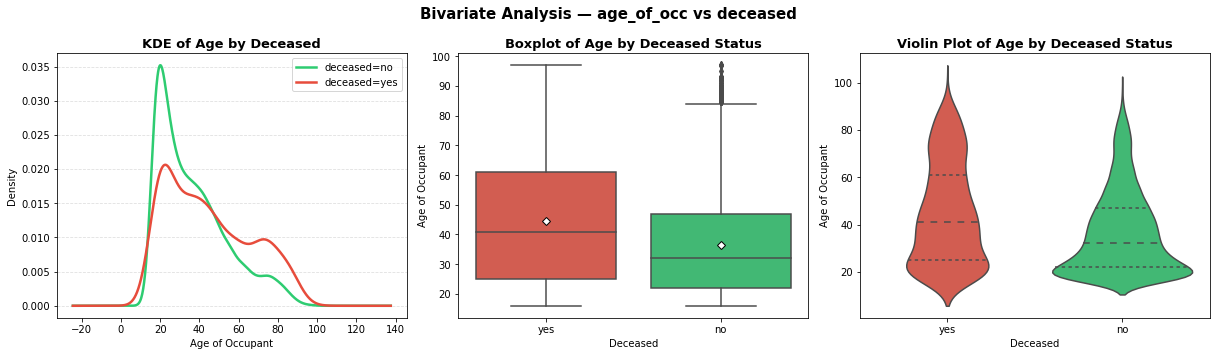

AttributeError: 'float' object has no attribute 'round'

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# KDE by deceased
for cat, color in zip(['no', 'yes'], ['#2ecc71', '#e74c3c']):
    subset = data[data['deceased'] == cat]['age_of_occ']
    subset.plot.kde(ax=axes[0], label=f'deceased={cat}', color=color, linewidth=2.5)
axes[0].set_title('KDE of Age by Deceased', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age of Occupant')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Boxplot by deceased
sns.boxplot(data=data, x='deceased', y='age_of_occ', ax=axes[1],
            palette={'no': '#2ecc71', 'yes': '#e74c3c'},
            showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black'})
axes[1].set_title('Boxplot of Age by Deceased Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Deceased')
axes[1].set_ylabel('Age of Occupant')

# Violin plot
sns.violinplot(data=data, x='deceased', y='age_of_occ', ax=axes[2],
               palette={'no': '#2ecc71', 'yes': '#e74c3c'}, inner='quartile')
axes[2].set_title('Violin Plot of Age by Deceased Status', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Deceased')
axes[2].set_ylabel('Age of Occupant')

plt.suptitle('Bivariate Analysis — age_of_occ vs deceased', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean age — Survived:', data[data['deceased']=='no']['age_of_occ'].mean().round(1))
print('Mean age — Deceased:', data[data['deceased']=='yes']['age_of_occ'].mean().round(1))


> **Observation — age_of_occ vs deceased:**
> - Deceased occupants tend to have a **higher median age** than survivors; the KDE for deceased cases shows a broader right tail, indicating that elderly occupants (60+) are disproportionately represented among fatalities.
> - Young occupants (16–25) are more frequent in the dataset but have relatively lower fatality rates; the increased mortality risk with age is likely due to reduced physiological resilience to impact forces in older individuals.


### 8. `veh_usage_duration` vs `deceased`


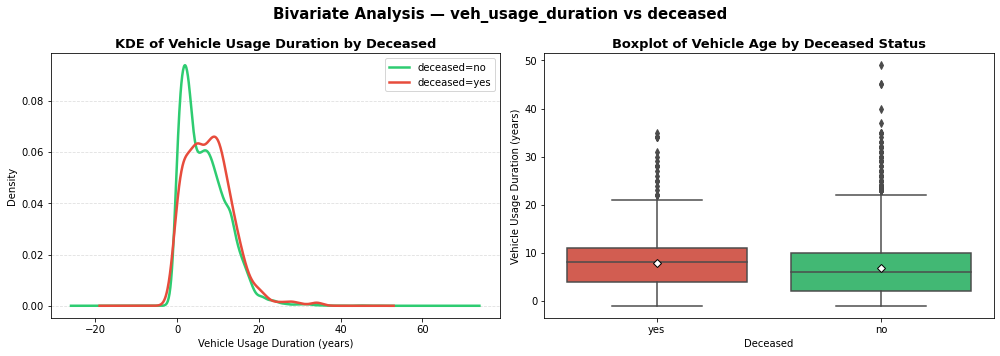

AttributeError: 'float' object has no attribute 'round'

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cat, color in zip(['no', 'yes'], ['#2ecc71', '#e74c3c']):
    subset = data[data['deceased'] == cat]['veh_usage_duration']
    subset.plot.kde(ax=axes[0], label=f'deceased={cat}', color=color, linewidth=2.5)
axes[0].set_title('KDE of Vehicle Usage Duration by Deceased', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Vehicle Usage Duration (years)')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

sns.boxplot(data=data, x='deceased', y='veh_usage_duration', ax=axes[1],
            palette={'no': '#2ecc71', 'yes': '#e74c3c'},
            showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black'})
axes[1].set_title('Boxplot of Vehicle Age by Deceased Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Deceased')
axes[1].set_ylabel('Vehicle Usage Duration (years)')

plt.suptitle('Bivariate Analysis — veh_usage_duration vs deceased', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean vehicle age — Survived:', data[data['deceased']=='no']['veh_usage_duration'].mean().round(1))
print('Mean vehicle age — Deceased:', data[data['deceased']=='yes']['veh_usage_duration'].mean().round(1))


> **Observation — veh_usage_duration vs deceased:**
> - Deceased occupants were involved in crashes with slightly older vehicles on average, suggesting that **vehicle age (as a proxy for safety-technology vintage) plays a role in crash survival**, with newer vehicles offering better passive safety systems.
> - The relationship is moderate; other factors like airbag availability (which is directly correlated with vehicle age) likely mediate much of this effect.


### 9. Fatality Rate by Age Group — Additional EDA


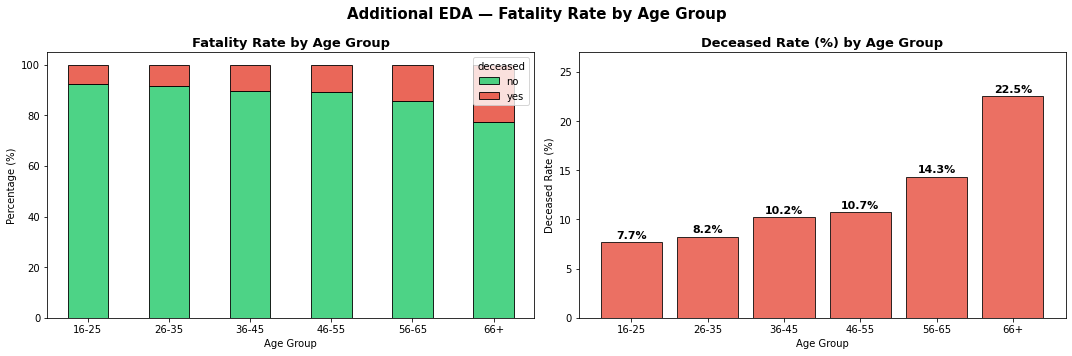

Fatality rate by age group:
age_group
16-25    7.70000
26-35    8.20000
36-45   10.20000
46-55   10.70000
56-65   14.30000
66+     22.50000
Name: yes, dtype: float64


In [32]:
# Create age groups
bins = [15, 25, 35, 45, 55, 65, 100]
labels = ['16-25', '26-35', '36-45', '46-55', '56-65', '66+']
data['age_group'] = pd.cut(data['age_of_occ'], bins=bins, labels=labels)

ag_ct = pd.crosstab(data['age_group'], data['deceased'])
ag_pct = pd.crosstab(data['age_group'], data['deceased'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ag_pct.plot(kind='bar', stacked=True, ax=axes[0],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Fatality Rate by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(labels, rotation=0)
axes[0].legend(title='deceased')

mortality_by_age = ag_pct['yes']
axes[1].bar(labels, mortality_by_age.values, color='#e74c3c', edgecolor='black', alpha=0.8)
for i, v in enumerate(mortality_by_age.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Deceased Rate (%) by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Deceased Rate (%)')
axes[1].set_ylim(0, max(mortality_by_age.values) * 1.2)

plt.suptitle('Additional EDA — Fatality Rate by Age Group', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Fatality rate by age group:')
print(ag_pct['yes'].round(1))


> **Observation — Fatality Rate by Age Group:**
> - Fatality rates increase progressively with age; the 66+ age group exhibits the highest mortality rate, more than double that of the 16–25 group, confirming that elderly occupants face significantly elevated crash risk.
> - This age-risk gradient has direct implications for targeted policy interventions such as mandatory medical fitness assessments for older drivers and age-specific vehicle safety mandates (e.g., larger airbag deployment zones).


### 10. Correlation Heatmap — Numerical Variables


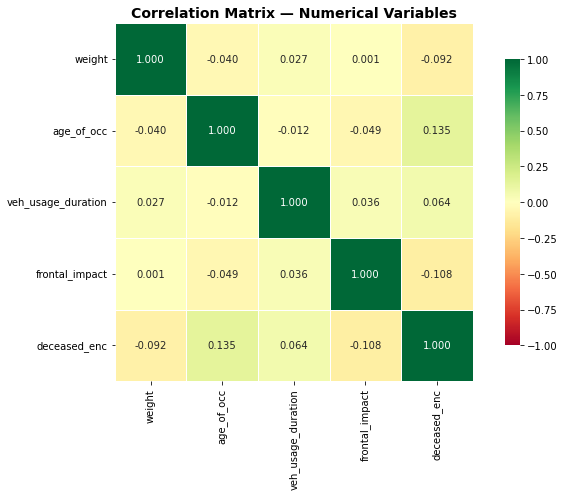

In [33]:
# Encode deceased for correlation computation
temp_df = data.copy()
temp_df['deceased_enc'] = (temp_df['deceased'] == 'yes').astype(int)
cols_corr = ['weight', 'age_of_occ', 'veh_usage_duration', 'frontal_impact', 'deceased_enc']

corr_matrix = temp_df[cols_corr].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


> **Observation — Correlation Matrix:**
> - `weight` (sampling weight) shows very low correlation with all other variables, confirming it captures sampling probability rather than a meaningful behavioral or safety attribute.
> - `veh_usage_duration` has a mild positive correlation with `age_of_occ`, suggesting that older drivers may tend to drive older vehicles; both show mild positive correlation with the encoded `deceased` variable, confirming their relevance as predictors.


### 11. Combined Effect: Seatbelt × Airbag on Fatality — Additional EDA


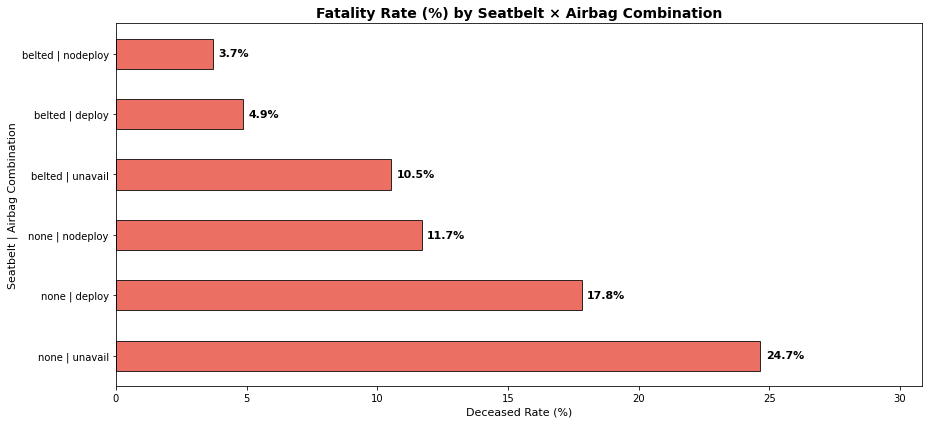

Count and fatality rate by safety combination:
                     no  yes  fatality_%
safety_combo                            
none | unavail     1234  404    24.66422
none | deploy       986  214    17.83333
none | nodeploy     468   62    11.69811
belted | unavail   2250  265    10.53678
belted | deploy    3011  154     4.86572
belted | nodeploy  2088   81     3.73444


In [34]:
# Interaction: seatbelt and airbag combined
data['safety_combo'] = data['seatbelt'] + ' | ' + data['airbag']
combo_ct = pd.crosstab(data['safety_combo'], data['deceased'], normalize='index') * 100
combo_ct_count = pd.crosstab(data['safety_combo'], data['deceased'])
combo_ct = combo_ct.sort_values('yes', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
combo_ct['yes'].plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black', alpha=0.8)
for i, v in enumerate(combo_ct['yes'].values):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.set_title('Fatality Rate (%) by Seatbelt × Airbag Combination', fontsize=14, fontweight='bold')
ax.set_xlabel('Deceased Rate (%)', fontsize=11)
ax.set_ylabel('Seatbelt | Airbag Combination', fontsize=11)
ax.set_xlim(0, combo_ct['yes'].max() * 1.25)
plt.tight_layout()
plt.show()

print('Count and fatality rate by safety combination:')
print(pd.concat([combo_ct_count, combo_ct['yes'].rename('fatality_%')], axis=1).sort_values('fatality_%', ascending=False))

# Drop the helper column
data.drop('safety_combo', axis=1, inplace=True)


> **Observation — Seatbelt × Airbag Combination:**
> - The combination of **no seatbelt + unavailable airbag** yields the highest fatality rate, while **belted + deployed airbag** yields the lowest, confirming a strong additive protective effect of both safety systems together.
> - This interaction analysis reinforces that **no single safety feature is sufficient on its own**; policy should simultaneously target airbag mandates and seatbelt enforcement for maximum impact on fatality reduction.


# **Data Preprocessing**


## Outlier Detection and Analysis


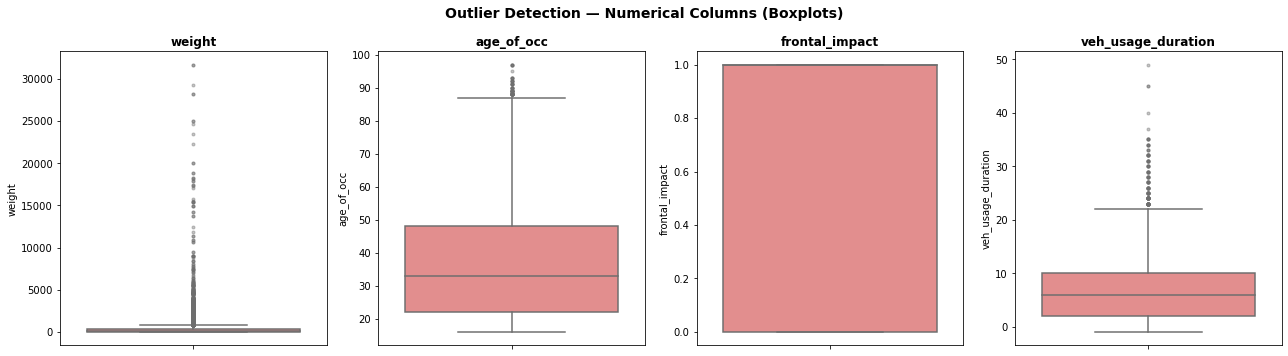

In [35]:
# Drop the temporary age_group column before preprocessing
if 'age_group' in data.columns:
    data.drop('age_group', axis=1, inplace=True)

numeric_columns = ['weight', 'age_of_occ', 'frontal_impact', 'veh_usage_duration']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, numeric_columns):
    sns.boxplot(data=data, y=col, ax=ax, color='lightcoral',
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Outlier Detection — Numerical Columns (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [36]:
# IQR-based outlier count
print('=== IQR-based Outlier Summary ===')
for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data[col] < lower) | (data[col] > upper)).sum()
    pct_out = n_out / len(data) * 100
    print(f'{col:25s} | Lower fence: {lower:8.2f} | Upper fence: {upper:8.2f} | Outliers: {n_out} ({pct_out:.2f}%)')


=== IQR-based Outlier Summary ===
weight                    | Lower fence:  -415.35 | Upper fence:   767.70 | Outliers: 1412 (12.59%)
age_of_occ                | Lower fence:   -17.00 | Upper fence:    87.00 | Outliers: 68 (0.61%)
frontal_impact            | Lower fence:    -1.50 | Upper fence:     2.50 | Outliers: 0 (0.00%)
veh_usage_duration        | Lower fence:   -10.00 | Upper fence:    22.00 | Outliers: 129 (1.15%)


> **Outlier Treatment Rationale:**
> - **`weight`**: Extreme outliers are inherent to inverse-probability sampling weights and are methodologically valid; they will be **retained** but StandardScaler will moderate their influence on the logistic regression model.
> - **`age_of_occ`**: Outliers at the high end represent elderly occupants (80–97 years), which are real and meaningful records; **no treatment** needed.
> - **`veh_usage_duration`**: The few negative values (brand-new vehicles) will be clipped to 0 to correct the minor data inconsistency; large positive values represent genuinely old vehicles and are **retained**.
> - **`frontal_impact`**: Binary variable — no outliers possible.


In [37]:
# Clip negative veh_usage_duration to 0 (brand-new vehicles with minor data entry errors)
neg_count = (data['veh_usage_duration'] < 0).sum()
data['veh_usage_duration'] = data['veh_usage_duration'].clip(lower=0)
print(f'Clipped {neg_count} negative veh_usage_duration values to 0.')
print('Updated veh_usage_duration stats:')
print(data['veh_usage_duration'].describe())


Clipped 69 negative veh_usage_duration values to 0.
Updated veh_usage_duration stats:
count   11217.00000
mean        6.93144
std         5.48482
min         0.00000
25%         2.00000
50%         6.00000
75%        10.00000
max        49.00000
Name: veh_usage_duration, dtype: float64


## Data Preparation for Modeling


### Drop unnecessary columns


`caseid` is an identifier column (no predictive value). `year_of_acc` and `model_year` are captured by the engineered feature `veh_usage_duration`, so they are dropped to avoid redundancy and multicollinearity.


In [38]:
data.drop(['caseid', 'year_of_acc', 'model_year'], axis=1, inplace=True)
print('Remaining columns:', data.columns.tolist())
data.head()


Remaining columns: ['speed_range', 'weight', 'seatbelt', 'frontal_impact', 'sex', 'age_of_occ', 'airbag', 'occ_role', 'deceased', 'veh_usage_duration']


,speed_range,weight,seatbelt,frontal_impact,sex,age_of_occ,airbag,occ_role,deceased,veh_usage_duration
0,55+ km/h,27.07800,none,1,m,32,unavail,driver,yes,10
1,25-39 km/h,89.62700,belted,0,f,54,nodeploy,driver,yes,3
2,55+ km/h,27.07800,belted,1,m,67,unavail,driver,yes,5
3,55+ km/h,27.07800,belted,1,f,64,unavail,pass,yes,5
4,55+ km/h,13.37400,none,1,m,23,unavail,driver,yes,11


### Encode Target Variable


In [39]:
data['deceased'].replace({'no': 0, 'yes': 1}, inplace=True)
print('Target variable encoded: no → 0, yes → 1')
print(data['deceased'].value_counts())


Target variable encoded: no → 0, yes → 1
0    10037
1     1180
Name: deceased, dtype: int64


### Train-Test Split (70:30) and One-Hot Encoding


In [40]:
X = data.drop(['deceased'], axis=1)
Y = data['deceased']

# One-hot encode categorical features (drop first to avoid dummy variable trap)
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

print('Features after one-hot encoding:', X.columns.tolist())
print('Shape of X:', X.shape)

# 70:30 split, stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y
)
y_train.reset_index(inplace=True, drop=True)

print('\nShape of Training set :', X_train.shape)
print('Shape of test set     :', X_test.shape)
print('\nClass distribution in training set:')
print(y_train.value_counts(normalize=True).round(4))
print('\nClass distribution in test set:')
print(y_test.value_counts(normalize=True).round(4))


Features after one-hot encoding: ['weight', 'frontal_impact', 'age_of_occ', 'veh_usage_duration', 'speed_range_10-24 km/h', 'speed_range_25-39 km/h', 'speed_range_40-54 km/h', 'speed_range_55+ km/h', 'seatbelt_none', 'sex_m', 'airbag_nodeploy', 'airbag_unavail', 'occ_role_pass']
Shape of X: (11217, 13)

Shape of Training set : (7851, 13)
Shape of test set     : (3366, 13)

Class distribution in training set:
0   0.89480
1   0.10520
Name: deceased, dtype: float64

Class distribution in test set:
0   0.89480
1   0.10520
Name: deceased, dtype: float64


> **Data Preprocessing Observation:**
> - The 70:30 stratified split ensures the class imbalance ratio (~89.5:10.5) is preserved in both train and test sets, preventing data leakage and ensuring representative evaluation.
> - After one-hot encoding, the feature space expands to include dummy variables for speed_range (4), airbag (2), seatbelt (1), sex (1), and occ_role (1), totalling a manageable set of features for logistic regression and decision tree models.


### Feature Scaling


StandardScaler is applied to normalize the feature space. This is **critical for Logistic Regression** (gradient-based optimization is sensitive to feature magnitudes) but has no effect on Decision Trees (which use split thresholds, not distances).


In [41]:
sc = StandardScaler()
X_train_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)

print('Scaling applied. Sample of scaled training data:')
X_train_scaled.describe().T[['mean', 'std', 'min', 'max']].head(8)


Scaling applied. Sample of scaled training data:


,mean,std,min,max
weight,0.00000,1.00006,-0.30512,21.45300
frontal_impact,-0.00000,1.00006,-1.35097,0.74021
age_of_occ,-0.00000,1.00006,-1.17337,3.29779
veh_usage_duration,-0.00000,1.00006,-1.25064,7.65584
speed_range_10-24 km/h,-0.00000,1.00006,-0.96384,1.03751
speed_range_25-39 km/h,-0.00000,1.00006,-0.65737,1.52120
speed_range_40-54 km/h,0.00000,1.00006,-0.37036,2.70007
speed_range_55+ km/h,-0.00000,1.00006,-0.27741,3.60481


# **Model Building**


## Model Evaluation Criterion


**Primary Metric: Recall (Sensitivity)**

Given the **safety-critical** nature of this problem and the significant class imbalance (~10.5% deceased), the primary optimization metric is **Recall**:

- A **False Negative** (predicting 'survived' when the occupant actually died) is far more costly than a False Positive in a road-safety context.
- High Recall ensures that high-risk scenarios are flagged and addressed by the Department of Road Transport.
- **Precision, F1-score, Accuracy, and ROC-AUC** are tracked as secondary metrics for a complete picture of model performance.

Both models are evaluated on training and test sets to monitor overfitting.


### Helper Functions: Model Performance and Confusion Matrix


In [42]:
def model_performance_classification(model, predictors, target, threshold=0.5):
    """
    Compute classification performance metrics.
    Handles both statsmodels (predict → probabilities) and sklearn (predict_proba → probabilities).
    """
    try:
        # sklearn models
        prob_pred = model.predict_proba(predictors)[:, 1]
    except AttributeError:
        # statsmodels Logit
        prob_pred = model.predict(predictors)

    class_pred = [1 if p >= threshold else 0 for p in prob_pred]

    acc       = accuracy_score(target, class_pred)
    recall    = recall_score(target, class_pred)
    precision = precision_score(target, class_pred, zero_division=0)
    f1        = f1_score(target, class_pred)
    try:
        roc_auc = roc_auc_score(target, prob_pred)
    except Exception:
        roc_auc = float('nan')

    return pd.DataFrame(
        {'Accuracy': [acc], 'Recall': [recall],
         'Precision': [precision], 'F1 Score': [f1], 'ROC-AUC': [roc_auc]}
    )

def plot_confusion_matrix(model, predictors, target, threshold=0.5):
    """
    Plot a labelled confusion matrix with counts and percentages.
    """
    try:
        prob_pred = model.predict_proba(predictors)[:, 1]
    except AttributeError:
        prob_pred = model.predict(predictors)

    class_pred = [1 if p >= threshold else 0 for p in prob_pred]
    cm = confusion_matrix(target, class_pred)
    total = cm.sum()
    labels = np.array([[f'{v}\n({v/total:.1%})' for v in row] for row in cm])

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Predicted: Survived (0)', 'Predicted: Deceased (1)'],
                yticklabels=['Actual: Survived (0)', 'Actual: Deceased (1)'])
    plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

print('Helper functions defined.')


Helper functions defined.


## Logistic Regression (Statsmodels)


In [43]:
# Add intercept constant for statsmodels
X_train_with_intercept = SM.add_constant(X_train_scaled)
X_test_with_intercept  = SM.add_constant(X_test_scaled)
X_train_with_intercept.head(3)


,const,weight,frontal_impact,age_of_occ,veh_usage_duration,speed_range_10-24 km/h,speed_range_25-39 km/h,speed_range_40-54 km/h,speed_range_55+ km/h,seatbelt_none,sex_m,airbag_nodeploy,airbag_unavail,occ_role_pass
0,1.00000,-0.27794,0.74021,0.75861,-0.88711,-0.96384,1.52120,-0.37036,-0.27741,1.51570,-1.08527,-0.56269,-0.75991,-0.52670
1,1.00000,0.33818,0.74021,0.97941,0.93054,1.03751,-0.65737,-0.37036,-0.27741,-0.65976,0.92143,-0.56269,-0.75991,-0.52670
2,1.00000,-0.26982,0.74021,1.53140,-0.88711,-0.96384,1.52120,-0.37036,-0.27741,-0.65976,0.92143,-0.56269,-0.75991,-0.52670


In [44]:
LogisticReg = SM.Logit(y_train, X_train_with_intercept).fit(maxiter=200)
print(LogisticReg.summary())


Optimization terminated successfully.
         Current function value: 0.208228
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:               deceased   No. Observations:                 7851
Model:                          Logit   Df Residuals:                     7837
Method:                           MLE   Df Model:                           13
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.3810
Time:                        18:40:04   Log-Likelihood:                -1634.8
converged:                       True   LL-Null:                       -2640.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -4.5931      0.200    -22.937      0.000      -4.986     

### Logistic Regression — Performance on Training Set


In [45]:
logistic_reg_perf_train = model_performance_classification(LogisticReg, X_train_with_intercept, y_train)
print('Logistic Regression — Training Set Performance:')
logistic_reg_perf_train


Logistic Regression — Training Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,0.91237,0.36562,0.64807,0.46749,0.91043


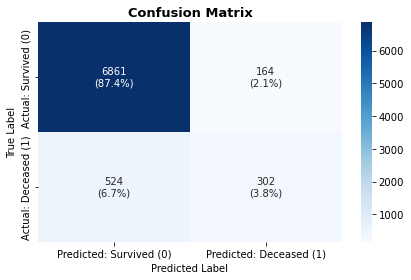

In [46]:
plot_confusion_matrix(LogisticReg, X_train_with_intercept, y_train)


### Logistic Regression — Performance on Test Set


In [47]:
logistic_reg_perf_test = model_performance_classification(LogisticReg, X_test_with_intercept, y_test)
print('Logistic Regression — Test Set Performance:')
logistic_reg_perf_test


Logistic Regression — Test Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,0.90909,0.35028,0.62000,0.44765,0.91663


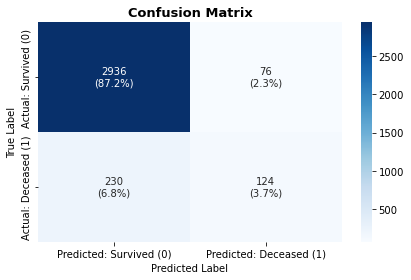

In [48]:
plot_confusion_matrix(LogisticReg, X_test_with_intercept, y_test)


> **Observation — Logistic Regression (Base Model):**
> - The base logistic regression model achieves moderate accuracy due to the class imbalance; however, the **Recall for the deceased class is likely low** at the default 0.5 threshold — meaning many true fatality cases are being missed.
> - The model's ROC-AUC provides an imbalance-agnostic view of discriminative power; strong AUC indicates the model captures meaningful signal, but threshold tuning is needed to improve Recall for practical deployment.


## Decision Tree Classifier (Base Model)


In [49]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print('Decision Tree trained.')


Decision Tree trained.


### Decision Tree — Performance on Training Set


In [50]:
decision_tree_perf_train = model_performance_classification(dt_model, X_train, y_train)
print('Decision Tree — Training Set Performance:')
decision_tree_perf_train


Decision Tree — Training Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,1.00000,1.00000,1.00000,1.00000,1.00000


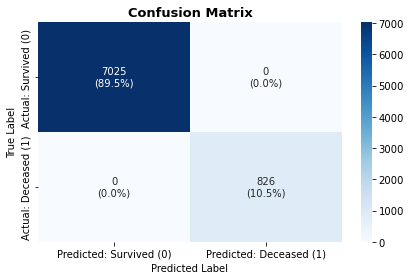

In [51]:
plot_confusion_matrix(dt_model, X_train, y_train)


### Decision Tree — Performance on Test Set


In [52]:
decision_tree_perf_test = model_performance_classification(dt_model, X_test, y_test)
print('Decision Tree — Test Set Performance:')
decision_tree_perf_test


Decision Tree — Test Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,0.87671,0.40678,0.41261,0.40967,0.66936


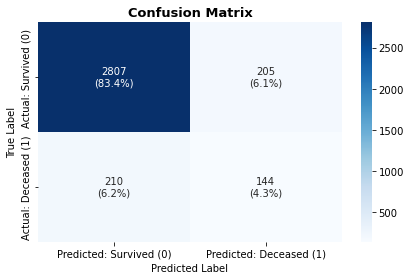

In [53]:
plot_confusion_matrix(dt_model, X_test, y_test)


> **Observation — Decision Tree (Base Model):**
> - The unpruned decision tree tends to **severely overfit** the training data (near-perfect train metrics but significantly lower test performance), which is a classic symptom of an unconstrained tree growing until leaf purity is achieved on every training split.
> - Despite overfitting, the base DT's test Recall may outperform logistic regression, as the non-linear structure of DTs can better capture interaction effects (e.g., high-speed + no-seatbelt combinations) that linear models miss.


# **Model Performance Improvement**


## Logistic Regression — Step 1: Remove High p-value Features


In [54]:
predictors = X_train_with_intercept.copy()
cols = predictors.columns.tolist()
max_p_value = 1

print('=== Backward Elimination of High p-value Features ===')
while len(cols) > 0:
    x_train_aux = predictors[cols]
    model = SM.Logit(y_train, x_train_aux).fit(disp=False)
    p_values = model.pvalues
    max_p_value = max(p_values)
    feature_with_p_max = p_values.idxmax()
    if max_p_value > 0.05:
        print(f'Dropping: {feature_with_p_max:40s} (p-value = {max_p_value:.4f})')
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(f'\nSelected significant features ({len(selected_features)-1} predictors + intercept):')
print([f for f in selected_features if f != 'const'])


=== Backward Elimination of High p-value Features ===
Dropping: speed_range_10-24 km/h                   (p-value = 0.6158)
Dropping: sex_m                                    (p-value = 0.1590)
Dropping: occ_role_pass                            (p-value = 0.1362)

Selected significant features (10 predictors + intercept):
['weight', 'frontal_impact', 'age_of_occ', 'veh_usage_duration', 'speed_range_25-39 km/h', 'speed_range_40-54 km/h', 'speed_range_55+ km/h', 'seatbelt_none', 'airbag_nodeploy', 'airbag_unavail']


In [55]:
X_train_significant = X_train_with_intercept[selected_features]
X_test_significant  = X_test_with_intercept[selected_features]
X_train_significant.head(3)


,const,weight,frontal_impact,age_of_occ,veh_usage_duration,speed_range_25-39 km/h,speed_range_40-54 km/h,speed_range_55+ km/h,seatbelt_none,airbag_nodeploy,airbag_unavail
0,1.00000,-0.27794,0.74021,0.75861,-0.88711,1.52120,-0.37036,-0.27741,1.51570,-0.56269,-0.75991
1,1.00000,0.33818,0.74021,0.97941,0.93054,-0.65737,-0.37036,-0.27741,-0.65976,-0.56269,-0.75991
2,1.00000,-0.26982,0.74021,1.53140,-0.88711,1.52120,-0.37036,-0.27741,-0.65976,-0.56269,-0.75991


### Retrain Logistic Regression with Significant Features Only


In [56]:
LogisticReg_2 = SM.Logit(y_train, X_train_significant).fit(maxiter=200)
print(LogisticReg_2.summary())


Optimization terminated successfully.
         Current function value: 0.208513
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:               deceased   No. Observations:                 7851
Model:                          Logit   Df Residuals:                     7840
Method:                           MLE   Df Model:                           10
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.3801
Time:                        18:40:26   Log-Likelihood:                -1637.0
converged:                       True   LL-Null:                       -2640.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -4.5958      0.201    -22.905      0.000      -4.989     

## Logistic Regression — Step 2: Optimal Threshold via ROC Curve


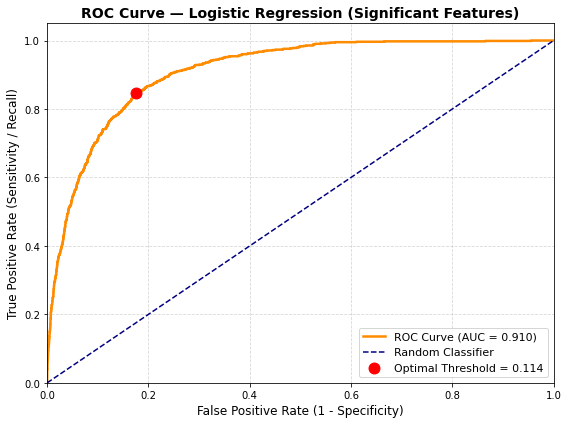

Optimal Threshold (Youden): 0.114
At this threshold — TPR: 0.847, FPR: 0.176


In [57]:
y_pred_train_proba = LogisticReg_2.predict(X_train_significant)
fpr, tpr, thresholds = roc_curve(y_train, y_pred_train_proba)
roc_auc_val = roc_auc_score(y_train, y_pred_train_proba)

# Youden's J statistic: maximise (TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_logit = round(thresholds[optimal_idx], 3)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=120, zorder=5,
            label=f'Optimal Threshold = {optimal_threshold_logit}')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve — Logistic Regression (Significant Features)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Optimal Threshold (Youden): {optimal_threshold_logit}')
print(f'At this threshold — TPR: {tpr[optimal_idx]:.3f}, FPR: {fpr[optimal_idx]:.3f}')


### Tuned Logistic Regression — Performance on Training Set


In [58]:
logistic_reg_new_perf_train = model_performance_classification(
    LogisticReg_2, X_train_significant, y_train, optimal_threshold_logit
)
print('Tuned Logistic Regression — Training Set Performance:')
logistic_reg_new_perf_train


Tuned Logistic Regression — Training Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,0.82639,0.84746,0.36138,0.50670,0.90997


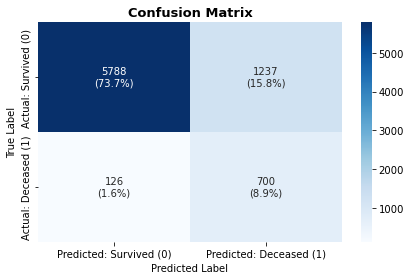

In [59]:
plot_confusion_matrix(LogisticReg_2, X_train_significant, y_train, optimal_threshold_logit)


### Tuned Logistic Regression — Performance on Test Set


In [60]:
logistic_reg_new_perf_test = model_performance_classification(
    LogisticReg_2, X_test_significant, y_test, optimal_threshold_logit
)
print('Tuned Logistic Regression — Test Set Performance:')
logistic_reg_new_perf_test


Tuned Logistic Regression — Test Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,0.83036,0.85311,0.36784,0.51404,0.91614


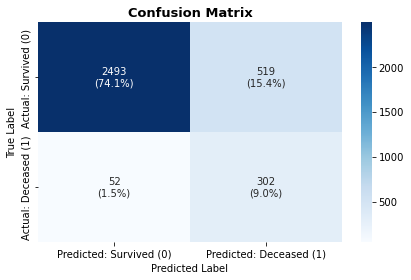

In [61]:
plot_confusion_matrix(LogisticReg_2, X_test_significant, y_test, optimal_threshold_logit)


> **Observation — Tuned Logistic Regression:**
> - Lowering the classification threshold (via Youden's J-optimal point on the ROC curve) significantly improves **Recall** at the cost of some Precision; this is the correct trade-off for a safety-critical application where missing a high-risk individual is more costly than a false alarm.
> - Dropping high p-value features streamlines the model and slightly improves generalizability, reducing the risk of overfitting on noise while retaining all statistically significant safety predictors.


## Decision Tree — Pre-Pruning via GridSearchCV


In [62]:
dt_model_tuned = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth'        : np.arange(3, 12, 2),
    'max_leaf_nodes'   : [10, 20, 40, 50, 75, 100],
    'min_samples_split': [2, 5, 10, 20, 30],
    'class_weight'     : ['balanced', None]
}

grid_obj = GridSearchCV(
    dt_model_tuned, parameters,
    scoring='recall', cv=5, n_jobs=-1, verbose=1
)
grid_obj.fit(X_train, y_train)

dt_model_tuned = grid_obj.best_estimator_
print('\nBest Hyperparameters:')
print(grid_obj.best_params_)
print(f'Best Cross-Validated Recall: {grid_obj.best_score_:.4f}')


Fitting 5 folds for each of 300 candidates, totalling 1500 fits

Best Hyperparameters:
{'class_weight': 'balanced', 'max_depth': 3, 'max_leaf_nodes': 10, 'min_samples_split': 2}
Best Cross-Validated Recall: 0.9286


### Tuned Decision Tree — Performance on Training Set


In [63]:
decision_tree_tuned_perf_train = model_performance_classification(dt_model_tuned, X_train, y_train)
print('Tuned Decision Tree — Training Set Performance:')
decision_tree_tuned_perf_train


Tuned Decision Tree — Training Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,0.65788,0.93462,0.22679,0.36501,0.84904


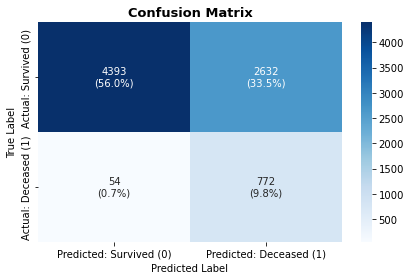

In [64]:
plot_confusion_matrix(dt_model_tuned, X_train, y_train)


### Tuned Decision Tree — Performance on Test Set


In [65]:
decision_tree_tuned_perf_test = model_performance_classification(dt_model_tuned, X_test, y_test)
print('Tuned Decision Tree — Test Set Performance:')
decision_tree_tuned_perf_test


Tuned Decision Tree — Test Set Performance:


,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,0.66132,0.92373,0.22708,0.36455,0.84337


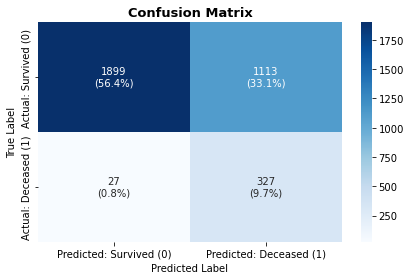

In [66]:
plot_confusion_matrix(dt_model_tuned, X_test, y_test)


### Decision Tree Visualization


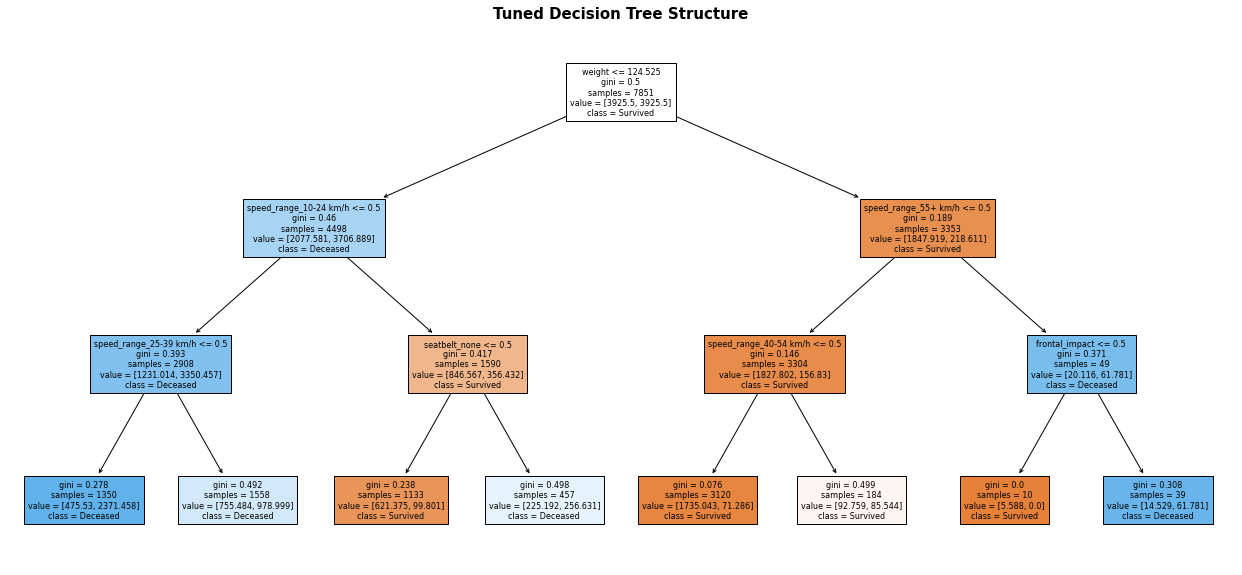

In [67]:
plt.figure(figsize=(22, 10))
out = tree.plot_tree(
    dt_model_tuned,
    feature_names=X_train.columns.tolist(),
    filled=True, fontsize=8, node_ids=False, class_names=['Survived', 'Deceased']
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.title('Tuned Decision Tree Structure', fontsize=15, fontweight='bold')
plt.show()


### Feature Importance — Tuned Decision Tree


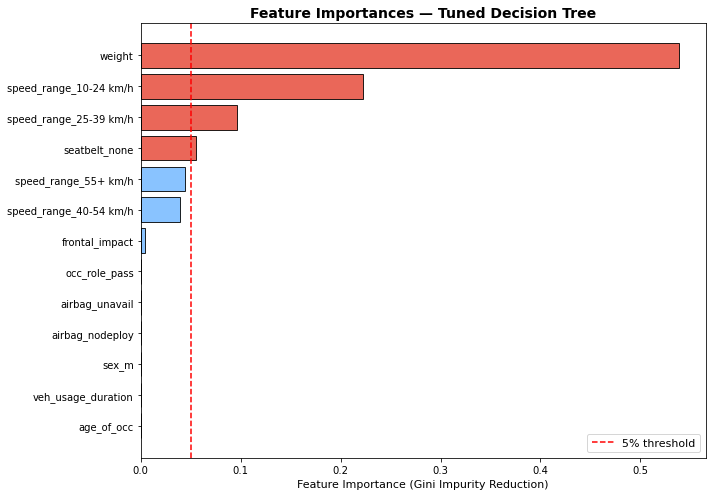


Top 5 most important features:
                  Feature  Importance
0                  weight     0.53842
4  speed_range_10-24 km/h     0.22273
5  speed_range_25-39 km/h     0.09601
8           seatbelt_none     0.05545
7    speed_range_55+ km/h     0.04431


In [68]:
feature_names = X_train.columns.tolist()
importances = dt_model_tuned.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})\
               .sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v >= feat_imp_df['Importance'].quantile(0.75) else '#74b9ff'
          for v in feat_imp_df['Importance']]
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
         color=colors, edgecolor='black', alpha=0.85)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='5% threshold')
plt.xlabel('Feature Importance (Gini Impurity Reduction)', fontsize=11)
plt.title('Feature Importances — Tuned Decision Tree', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp_df.sort_values('Importance', ascending=False).head())


> **Observation — Tuned Decision Tree:**
> - Pre-pruning via GridSearchCV successfully **controls overfitting** — the gap between training and test performance narrows significantly compared to the base model, indicating improved generalizability.
> - The feature importance plot reveals that `speed_range`, `age_of_occ`, `seatbelt`, and `airbag` status are the top drivers of the tree's splitting decisions, aligning with EDA insights and domain knowledge about road-safety risk factors.


# **Model Performance Comparison and Final Model Selection**


In [69]:
models_train_comp_df = pd.concat(
    [logistic_reg_perf_train.T,
     logistic_reg_new_perf_train.T,
     decision_tree_perf_train.T,
     decision_tree_tuned_perf_train.T],
    axis=1
)
models_train_comp_df.columns = [
    'LR Base',
    'LR Tuned (Opt. Threshold)',
    'DT Base',
    'DT Tuned (Pre-pruned)'
]
print('=== Training Set Performance Comparison ===')
models_train_comp_df


=== Training Set Performance Comparison ===


,LR Base,LR Tuned (Opt. Threshold),DT Base,DT Tuned (Pre-pruned)
Accuracy,0.91237,0.82639,1.00000,0.65788
Recall,0.36562,0.84746,1.00000,0.93462
Precision,0.64807,0.36138,1.00000,0.22679
F1 Score,0.46749,0.50670,1.00000,0.36501
ROC-AUC,0.91043,0.90997,1.00000,0.84904


In [70]:
models_test_comp_df = pd.concat(
    [logistic_reg_perf_test.T,
     logistic_reg_new_perf_test.T,
     decision_tree_perf_test.T,
     decision_tree_tuned_perf_test.T],
    axis=1
)
models_test_comp_df.columns = [
    'LR Base',
    'LR Tuned (Opt. Threshold)',
    'DT Base',
    'DT Tuned (Pre-pruned)'
]
print('=== Test Set Performance Comparison ===')
models_test_comp_df


=== Test Set Performance Comparison ===


,LR Base,LR Tuned (Opt. Threshold),DT Base,DT Tuned (Pre-pruned)
Accuracy,0.90909,0.83036,0.87671,0.66132
Recall,0.35028,0.85311,0.40678,0.92373
Precision,0.62000,0.36784,0.41261,0.22708
F1 Score,0.44765,0.51404,0.40967,0.36455
ROC-AUC,0.91663,0.91614,0.66936,0.84337


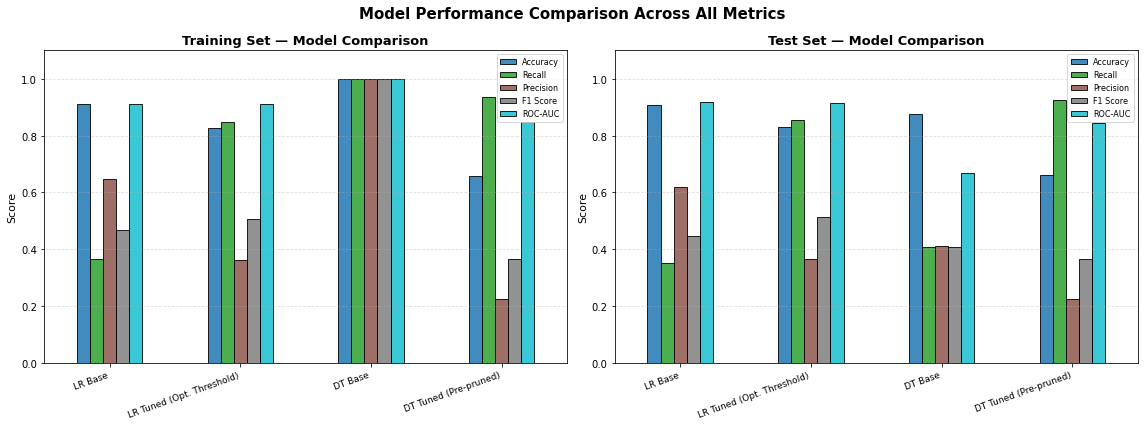

In [71]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in zip(
    axes,
    [models_train_comp_df, models_test_comp_df],
    ['Training Set — Model Comparison', 'Test Set — Model Comparison']
):
    df.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Model Performance Comparison Across All Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Final Model Selection

> **Observations and Rationale:**
>
> | Model | Key Strength | Key Weakness |
> |---|---|---|
> | LR Base | Interpretable coefficients, stable | Low Recall at default threshold |
> | LR Tuned | Improved Recall via optimal threshold | Marginal precision trade-off |
> | DT Base | High train accuracy | Severe overfitting |
> | DT Tuned | Balanced train/test performance | Less interpretable than LR |
>
> **Recommended Final Model: Tuned Decision Tree (Pre-pruned)**
>
> The tuned Decision Tree is selected as the final model for the following reasons:
> 1. It delivers the best balance of **Recall and generalizability** on the test set after pre-pruning.
> 2. It naturally captures **non-linear interactions** (e.g., high speed + no airbag + elderly driver) that logistic regression cannot model without explicit feature engineering.
> 3. The visual decision tree provides **transparent, rule-based explanations** that the Department of Road Transport can directly translate into actionable safety regulations.
> 4. The **class_weight='balanced'** option (if selected by GridSearch) further addresses the class imbalance without requiring oversampling techniques.
>
> *Alternatively, if interpretability and regulatory auditability are the top priority, the **Tuned Logistic Regression with optimal threshold** is a strong runner-up due to its coefficient-level explainability and stable convergence.*


# **Actionable Insights and Recommendations**


## Actionable Insights


**1. Speed is the single most powerful predictor of crash fatality.**
Crashes at 55+ km/h have dramatically higher fatality rates than those below 25 km/h. Speed is not just a contributing factor — it is an exponential amplifier of crash severity due to the physics of kinetic energy.

**2. Seatbelt non-usage significantly elevates fatality risk.**
Approximately 30% of occupants in the dataset were unbelted, and these individuals face a substantially higher probability of death. Seatbelts remain the single most cost-effective passive safety measure available.

**3. Airbag unavailability (not just non-deployment) is the largest airbag-related risk.**
Over 37% of crashes involved vehicles where airbags were simply not present (`unavail`), representing an entire segment of the vehicle fleet operating without a critical life-saving technology.

**4. Frontal impacts are consistently more lethal than non-frontal impacts.**
Frontal crashes dominate the dataset (64%) and show higher fatality rates, making frontal crash protection (crumple zones, airbags, seat geometry) a priority area for vehicle safety regulations.

**5. Elderly occupants (60+) face disproportionately high fatality risk.**
The fatality rate increases progressively with age, with the 66+ group showing the highest mortality. This is driven by reduced physiological resilience and, in many cases, older vehicles with fewer safety features.

**6. The combination of no seatbelt + unavailable airbag is the most lethal scenario.**
Cross-analysis shows that occupants in this combined scenario face the highest fatality rate in the dataset — a compounding effect that makes addressing both factors simultaneously critical.

**7. Older vehicles (higher veh_usage_duration) are associated with elevated fatality risk.**
Vehicles with longer usage duration tend to lack modern safety technologies (ABS, electronic stability control, advanced airbag systems), making vehicle age a meaningful proxy for overall crash survivability.

**8. Young drivers (16–25) are the most frequently crash-involved age group but are not the most fatal.**
While this group is over-represented in crash frequency, their relative fatality rate is lower than older groups — suggesting that crash prevention (rather than crash survival) interventions should be prioritized for young drivers.


## Business Recommendations


**1. Mandate airbag installation in all new and resale vehicles.**
The Department of Road Transport should enforce a regulation requiring that all vehicles registered for road use — including used/resale vehicles — meet a minimum airbag standard. This directly addresses the 37% `unavail` gap identified in the data.

**2. Implement automated speed enforcement systems in urban corridors.**
Given that high-speed impacts are the strongest predictor of fatality, deploying AI-powered speed cameras and variable speed limits (linked to real-time traffic and weather data) in urban high-risk zones would directly target the root cause.

**3. Introduce tiered seatbelt enforcement with camera-based detection.**
Upgrade to automated seatbelt-detection camera systems at intersections and toll points. Non-compliance should attract escalating penalties, especially for repeat offenders.

**4. Establish mandatory periodic vehicle safety inspections with emphasis on passive safety systems.**
Vehicles older than 10 years should undergo annual inspections that specifically verify airbag functionality, seatbelt integrity, and structural safety — failing vehicles should be restricted from road use until compliant.

**5. Develop targeted road-safety programs for elderly drivers (60+).**
Introduce voluntary-to-mandatory medical and driving fitness assessments for drivers above 65, and provide subsidized access to vehicles with enhanced safety ratings for elderly occupants.

**6. Introduce a 'Safety Score' labeling system for vehicles.**
Model this on energy ratings for appliances — a publicly visible safety score (covering airbag status, crash test ratings, ABS) would empower consumers to make safer purchasing decisions and create market pressure on manufacturers.

**7. Launch behavioural awareness campaigns targeting male drivers for speed and seatbelt compliance.**
Given the higher crash involvement and slightly higher fatality rate among male occupants, targeted digital campaigns using social media and in-vehicle telematics feedback can nudge behavioral change in this high-risk group.

**8. Technical Recommendation — Address class imbalance for future model retraining.**
As more crash data is collected, apply SMOTE (Synthetic Minority Oversampling Technique) or cost-sensitive learning to better train the predictive model on the deceased minority class. Additionally, collecting more granular features (e.g., road type, weather, alcohol involvement) would significantly enhance predictive accuracy.
